In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("../data/processed/ai_jobs_copy.csv")

In [3]:
df.groupby("ai_specialization")["salary_usd"].mean().round(2)
df.groupby("ai_specialization")["salary_usd"].median().round(2)


df["salary_usd"].median()

df["salary_usd"].min()
df["salary_usd"].max()
df["salary_usd"].mean()

df.groupby("ai_specialization")["salary_usd"].min()


pd.pivot_table(
    df,
    index= "ai_specialization",
    values = "salary_usd",
    aggfunc = "max"
)
# OR

df.groupby("ai_specialization")["salary_usd"].median().sort_values(ascending=False)
df.groupby("ai_specialization")["salary_usd"].agg(
    ["count", "mean", "median" ,"max"]
).round(2)


ai_sal_agg = (
    df.groupby("ai_specialization")
    .agg(
        Median_Salary = ("salary_usd", "median"),
        Job_Layoff_Risk_Rate = ("layoff_risk", "median")
    )
    .reset_index()
)

print(ai_sal_agg)

        ai_specialization  Median_Salary  Job_Layoff_Risk_Rate
0               Analytics        87892.0                 0.141
1         Computer Vision        88080.0                 0.139
2             Forecasting        87063.0                 0.141
3           Generative AI        87253.0                 0.141
4                     LLM        88086.0                 0.139
5                   MLOps        87644.0                 0.142
6                     NLP        87936.5                 0.140
7  Reinforcement Learning        86191.0                 0.142


In [4]:
df.groupby("ai_specialization")["job_openings"]

pd.pivot_table(
    df,
    index= "ai_specialization",
    values = "job_openings",
    aggfunc = "median"
)
df.groupby("ai_specialization")["job_security_score"].max()

df.groupby("ai_specialization")["career_growth_score"].max()

data = df.groupby("ai_specialization")["salary_usd"].max().sort_values(ascending=False)

# print(data)

job_security_specialization = (
    df.groupby("ai_specialization")
    .agg(
         job_median_sal = ("salary_usd", "median"),
         job_median_security = ("job_security_score", "median")
    )
    .reset_index()
)

print(job_security_specialization)

        ai_specialization  job_median_sal  job_median_security
0               Analytics         87892.0                 77.0
1         Computer Vision         88080.0                 77.0
2             Forecasting         87063.0                 77.0
3           Generative AI         87253.0                 77.0
4                     LLM         88086.0                 77.0
5                   MLOps         87644.0                 77.0
6                     NLP         87936.5                 77.0
7  Reinforcement Learning         86191.0                 77.0


In [5]:
# df.groupby("country")["layoff_risk"].median().sort_values()

# Country wise
job_security_country = (df.groupby("country")
                 .agg(
                      Median_layoff_risk = ("layoff_risk", "median"),
                      Median_Job_Security_Score = ("job_security_score", "median")
                 )
                 .sort_values(by="Median_layoff_risk", ascending=False)
             )

job_security_industry = (df.groupby(["industry", "country"])
                 .agg(
                      Median_layoff_risk = ("layoff_risk", "median"),
                      Median_Job_Security_Score = ("job_security_score", "median")
                 )
                 .sort_values(by="Median_layoff_risk", ascending=False)
             ).head(10)
# print(job_security_country)

print()

print(job_security_industry)


                        Median_layoff_risk  Median_Job_Security_Score
industry   country                                                   
Automotive Australia                0.1530                       77.0
Energy     Brazil                   0.1520                       77.0
Consulting Canada                   0.1515                       76.0
           Netherlands              0.1510                       77.0
Tech       UK                       0.1510                       76.0
Education  UK                       0.1500                       76.0
Healthcare Brazil                   0.1500                       77.0
Finance    Netherlands              0.1500                       77.0
Telecom    Canada                   0.1500                       77.0
Retail     Brazil                   0.1480                       76.0


In [6]:
df["ERI"] = np.where(
    df["experience_years"] > 0,
    df["salary_usd"] / df["experience_years"],
    np.nan
).round(2)

df["ERI"]

specialization_summary = (
    df.groupby("ai_specialization")
      .agg(
          Median_ERI=("ERI", "median"),
        #   Median_Hiring_Difficulty=("hiring_difficulty_score", "median"),
        #   Median_Salary=("salary_usd", "median"),
        #   Median_Career_Growth=("career_growth_score", "median")
      )
      .sort_values(by="Median_ERI", ascending=False)
      .reset_index()
)


print(specialization_summary)

        ai_specialization  Median_ERI
0               Analytics   14329.660
1                   MLOps   14078.570
2                     LLM   14077.400
3             Forecasting   14077.000
4                     NLP   14070.835
5  Reinforcement Learning   14029.250
6           Generative AI   13964.420
7         Computer Vision   13839.225


In [7]:
career_growth_summary = (df.groupby("education_required")
            .agg(
                Median_Hiring_Difficulty=("hiring_difficulty_score", "median"),
                Median_Salary=("salary_usd", "median"),
                Median_Career_Growth=("career_growth_score", "median")
            )
            .sort_values(
                by="Median_Career_Growth",
                ascending=False
                )
            )

print(career_growth_summary)

                    Median_Hiring_Difficulty  Median_Salary  \
education_required                                            
Bachelor                           55.029591        87710.0   
Bootcamp                           55.167012        88233.0   
Diploma                            54.837081        87356.5   
Master                             55.235560        86946.0   
PhD                                55.079819        87465.0   

                    Median_Career_Growth  
education_required                        
Bachelor                            57.0  
Bootcamp                            57.0  
Diploma                             57.0  
Master                              57.0  
PhD                                 57.0  


In [8]:
work_life_balance_summary = (df.groupby("work_mode")
            .agg(
                Median_Salary=("salary_usd", "median"),
                Median_Career_Growth=("career_growth_score", "median"),
                Median_Work_Life_Balance=("work_life_balance_score", "median")
            )
            .sort_values(
                by="Median_Career_Growth",
                ascending=False
                )
            )

print(work_life_balance_summary)

           Median_Salary  Median_Career_Growth  Median_Work_Life_Balance
work_mode                                                               
Hybrid           87639.0                  57.0                      69.0
Onsite           87255.0                  57.0                      69.0
Remote           87732.0                  57.0                      69.0


In [9]:
df.describe()

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction,ERI
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,78844.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,0.179706,71.375167,4.848425,72.518162,8.518878,75.009412,27.005793,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100,22196.254901
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,0.131371,13.767769,2.681073,15.881720,3.453179,11.514932,8.664666,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018,20172.027228
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,0.000000,1.000000,0.200000,45.000000,3.000000,55.000000,12.000000,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000,2201.320000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,0.078000,62.000000,2.530000,58.730000,6.000000,65.070000,19.500000,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000,9977.410000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,0.140000,71.000000,4.840000,72.580000,9.000000,75.000000,27.000000,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000,14051.560000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,0.276000,81.000000,7.170000,86.260000,12.000000,84.990000,34.500000,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000,25348.980000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,0.588000,100.000000,9.500000,100.000000,14.000000,95.000000,42.000000,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000,119807.000000


In [10]:
df[["experience_years",	"salary_usd",	"bonus_usd", "interview_rounds",
"weekly_hours",	"company_rating",	"job_openings",	"hiring_difficulty_score",	"layoff_risk",	"ai_adoption_score",	"company_funding_billion",	"economic_index",	"ai_maturity_years",	"offer_acceptance_rate",	"tax_rate_percent",	"vacation_days",	"skill_demand_score",	"automation_risk",	"job_security_score",	"career_growth_score",	"work_life_balance_score",	"promotion_speed",	"salary_percentile",	"cost_of_living_index",	"employee_satisfaction"
]].agg(
    ["min", "max", "mean", "median"]
).round(2)

,experience_years,salary_usd,bonus_usd,interview_rounds,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
min,0.00,28000.00,1404.00,2.0,36.00,3.2,1.00,0.00,0.00,1.00,0.20,45.00,3.00,55.00,12.00,10.00,1.00,1.00,29.00,25.0,25.00,12.00,1.00,0.50,42.00
max,19.00,300622.00,57681.00,7.0,55.00,4.8,50.00,100.00,0.59,100.00,9.50,100.00,14.00,95.00,42.00,30.00,100.00,100.00,99.00,99.0,98.00,98.00,100.00,2.50,99.00
mean,7.03,96546.25,13028.42,4.5,45.48,4.0,17.52,55.03,0.18,71.38,4.85,72.52,8.52,75.01,27.01,19.99,50.46,50.36,75.56,57.2,69.15,38.44,50.54,1.50,72.73
median,6.00,87544.00,11279.00,4.0,45.50,4.0,17.00,55.07,0.14,71.00,4.84,72.58,9.00,75.00,27.00,20.00,51.00,50.00,77.00,57.0,69.00,37.00,51.00,1.51,73.00


In [11]:
job_demand_summary = (df.groupby("job_role")
            .agg(
                Median_Salary=("salary_usd", "median"),
                Median_Hiring_Difficulty=("hiring_difficulty_score", "median"),
                Median_Interview_Rounds=("interview_rounds", "median"),
                Median_Skill_Demand=("skill_demand_score", "median"),
                Median_Work_Life_Balance=("work_life_balance_score", "median")
            )
            .sort_values(
                by="Median_Salary",
                ascending=False
                )
            )

print(job_demand_summary)

                           Median_Salary  Median_Hiring_Difficulty  \
job_role                                                             
Research Scientist               99659.0                 55.136566   
Machine Learning Engineer        93257.0                 54.913768   
Computer Vision Engineer         91730.0                 55.023931   
NLP Engineer                     90826.0                 55.098163   
Software Engineer AI             88723.0                 54.906696   
AI Engineer                      88501.0                 55.114490   
Data Scientist                   85501.5                 55.103084   
Data Analyst                     62657.0                 55.137036   

                           Median_Interview_Rounds  Median_Skill_Demand  \
job_role                                                                  
Research Scientist                             5.0                 50.0   
Machine Learning Engineer                      5.0                 50.0   

In [12]:
ai_demand_summary = (df.groupby("ai_specialization")
            .agg(
                Median_Salary=("salary_usd", "median"),
                Median_Hiring_Difficulty=("hiring_difficulty_score", "median"),
                Median_Interview_Rounds=("interview_rounds", "median"),
                Median_Skill_Demand=("skill_demand_score", "median"),
            )
            .sort_values(
                by="Median_Salary",
                ascending=False
                )
            )

print(ai_demand_summary)

                        Median_Salary  Median_Hiring_Difficulty  \
ai_specialization                                                 
LLM                           88086.0                 55.041455   
Computer Vision               88080.0                 54.910372   
NLP                           87936.5                 55.444714   
Analytics                     87892.0                 55.115330   
MLOps                         87644.0                 55.204715   
Generative AI                 87253.0                 54.825941   
Forecasting                   87063.0                 54.905601   
Reinforcement Learning        86191.0                 55.093206   

                        Median_Interview_Rounds  Median_Skill_Demand  
ai_specialization                                                     
LLM                                         5.0                 51.0  
Computer Vision                             4.0                 50.0  
NLP                                         4

In [13]:
df.groupby("experience_level")["salary_usd"].median().sort_values(ascending=False)

experience_level
Lead      146926.5
Senior    107619.0
Mid        79970.0
Entry      63542.0
Name: salary_usd, dtype: float64

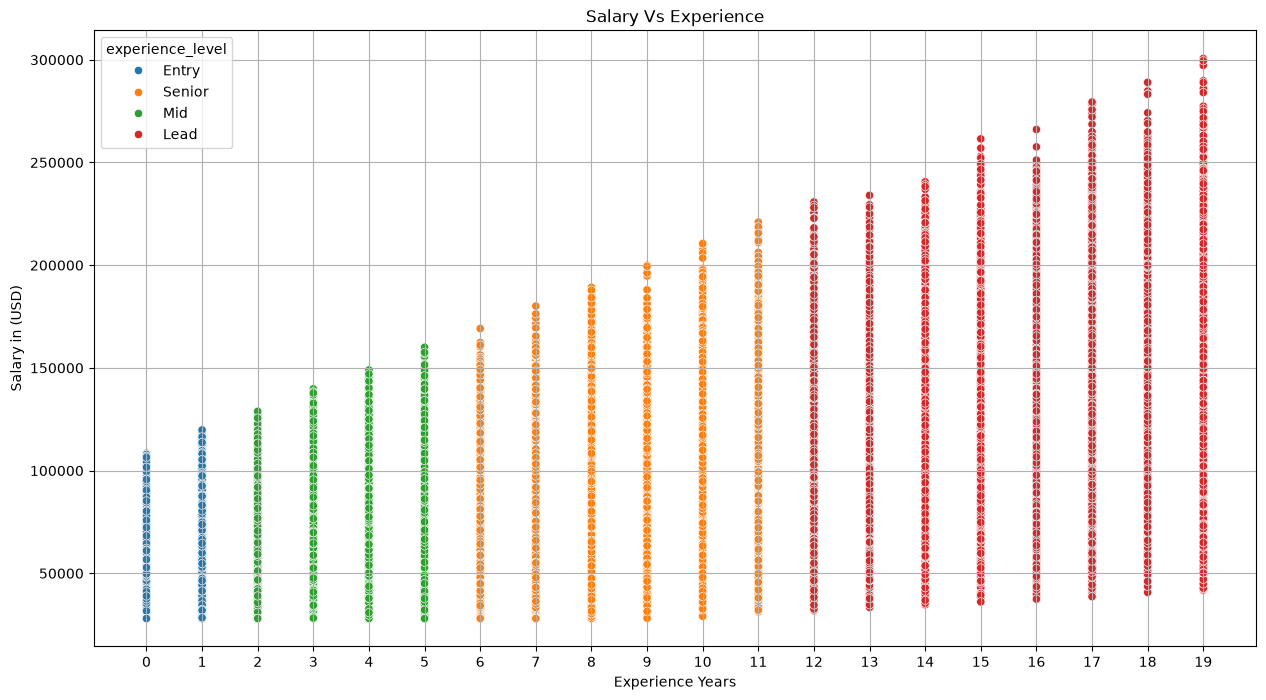

In [14]:
fig, ax = plt.subplots(figsize=(15,8))

sns.scatterplot(
    data=df,
    x = "experience_years",
    y = "salary_usd",
    hue = "experience_level",
)

ax.set_xlabel("Experience Years")
ax.set_ylabel("Salary in (USD)")

ax.set_xticks(df["experience_years"].unique())
# ax.set_yticks(df["salary_usd"].unique())

ax.set_title("Salary Vs Experience")
plt.grid()

plt.show()


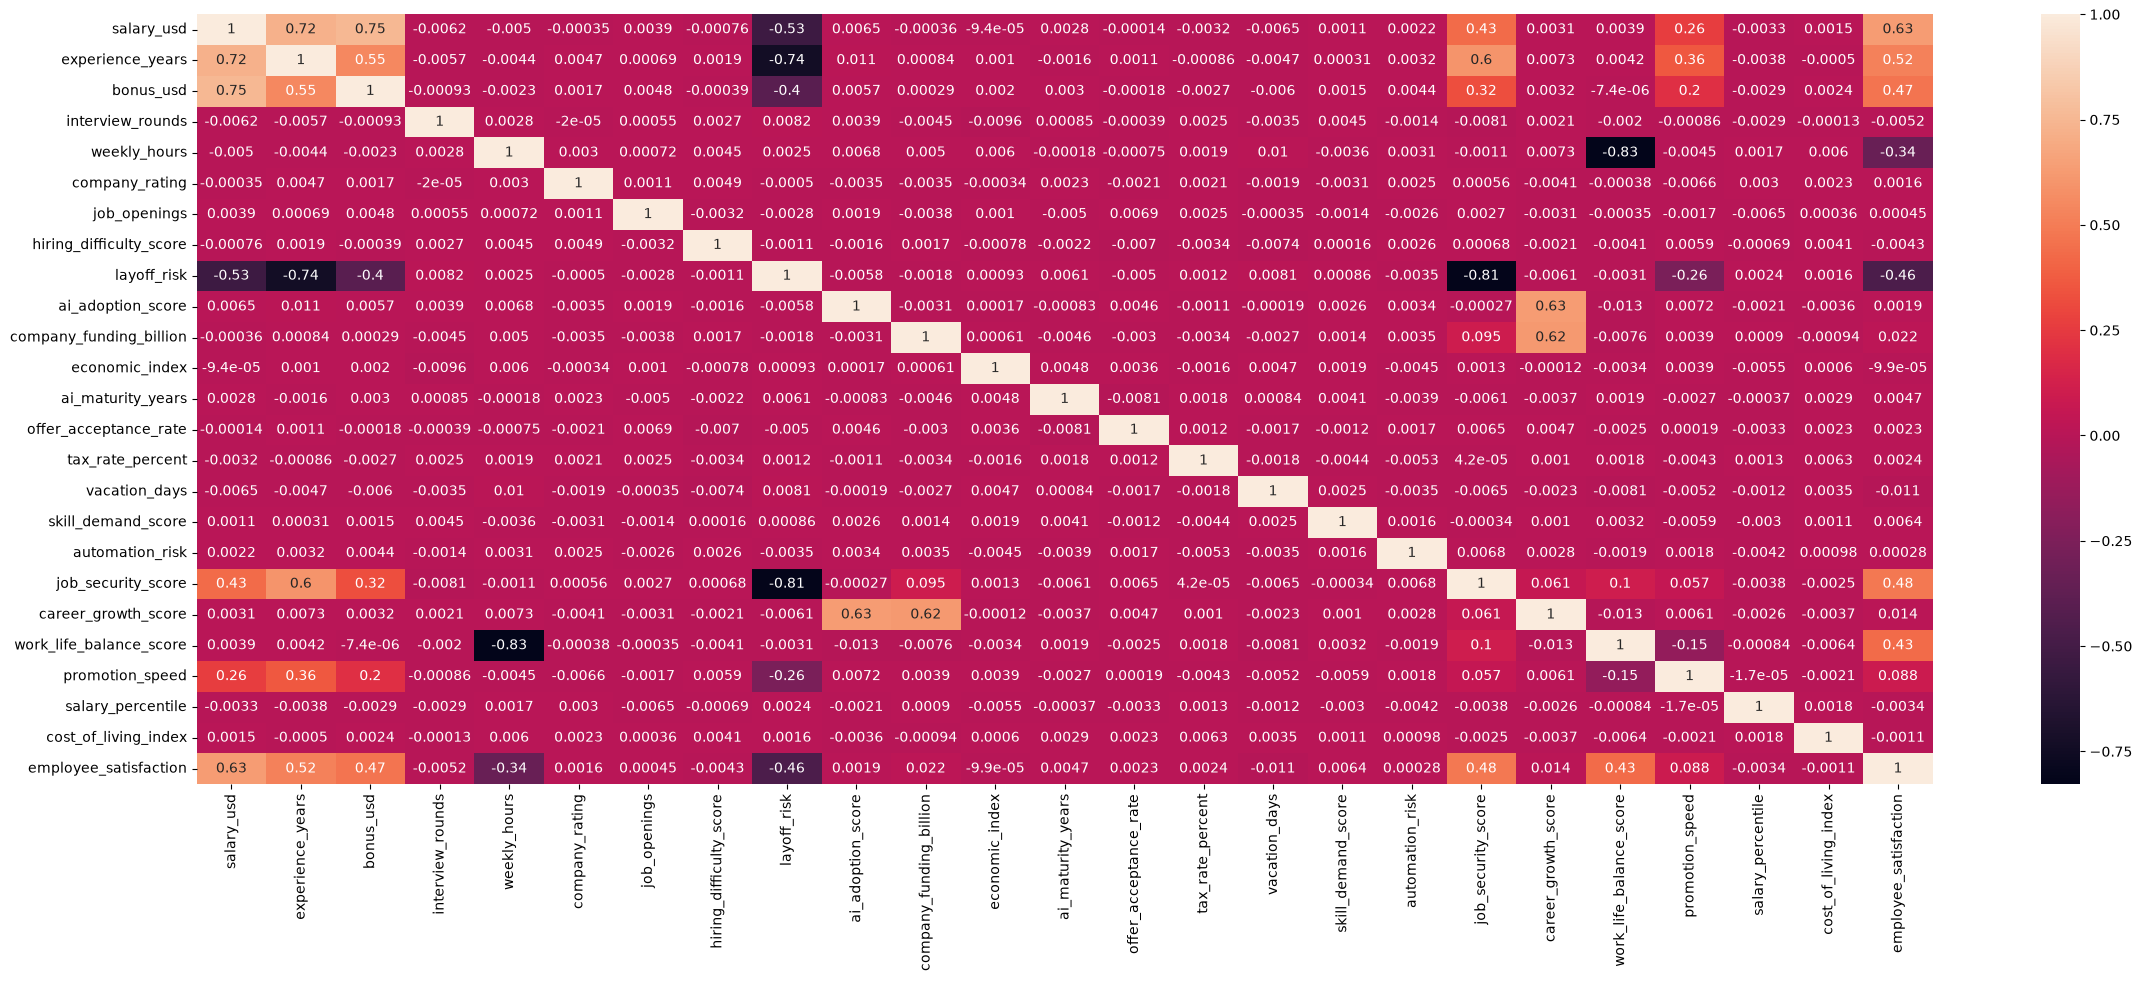

salary_usd                 1.000000
bonus_usd                  0.752046
experience_years           0.723879
employee_satisfaction      0.629030
job_security_score         0.434177
promotion_speed            0.261381
ai_adoption_score          0.006550
work_life_balance_score    0.003890
job_openings               0.003853
career_growth_score        0.003107
ai_maturity_years          0.002797
automation_risk            0.002201
cost_of_living_index       0.001462
skill_demand_score         0.001087
economic_index            -0.000094
offer_acceptance_rate     -0.000143
company_rating            -0.000347
company_funding_billion   -0.000362
hiring_difficulty_score   -0.000759
tax_rate_percent          -0.003189
salary_percentile         -0.003327
weekly_hours              -0.004970
interview_rounds          -0.006230
vacation_days             -0.006457
layoff_risk               -0.533439
Name: salary_usd, dtype: float64

In [15]:
numerical_cols = ["salary_usd",
                  "experience_years",
                      "bonus_usd",
                      "interview_rounds",
                      "weekly_hours",
                      "company_rating",
                      "job_openings",
                      "hiring_difficulty_score",
                      "layoff_risk",
                      "ai_adoption_score",
                      "company_funding_billion",
                      "economic_index",
                      "ai_maturity_years",
                      "offer_acceptance_rate",
                      "tax_rate_percent",
                      "vacation_days",
                      "skill_demand_score",
                      "automation_risk",
                      "job_security_score",
                      "career_growth_score",
                      "work_life_balance_score",
                      "promotion_speed",
                      "salary_percentile",
                      "cost_of_living_index",
                      "employee_satisfaction"
                      ]

correlation_matrix = (
    df[numerical_cols].corr()
)

# print(correlation_matrix)

fig, ax = plt.subplots(figsize=(28,10))


sns.heatmap(
    correlation_matrix,
    annot=True,
    # fmt=".0f",
    ax=ax
    )


plt.show()

correlation_matrix["salary_usd"].sort_values(ascending=False)

               Median_Salary  Median_Satisfaction  Median_Job_Security
salary_bands                                                          
Low earner           56214.0                 68.0                 69.0
Medium earner        87544.0                 72.0                 76.0
High earner         141847.5                 79.0                 83.0


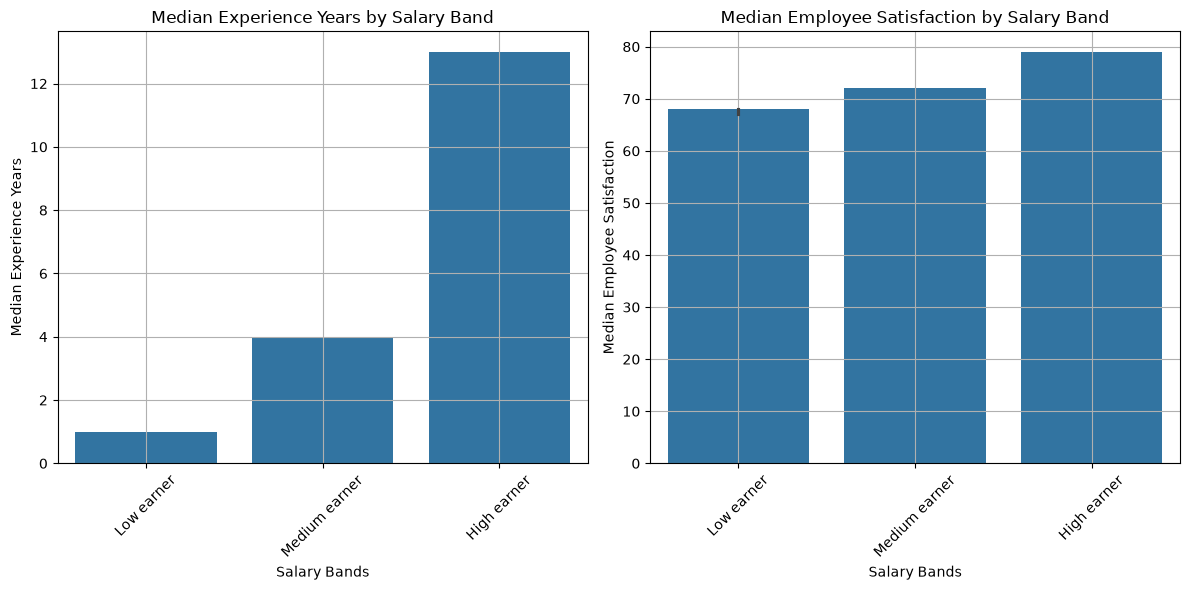

In [16]:
df["salary_bands"] = pd.qcut(
    df["salary_usd"],
    q=3,
    labels = ["Low earner", "Medium earner", "High earner"]
)

df["salary_bands"].value_counts()


salary_driver_analysis = (
    df.groupby("salary_bands")
    .agg(
        Median_Salary = ("salary_usd", "median"),
        Median_Satisfaction = ("employee_satisfaction", "median"),
        Median_Job_Security = ("job_security_score", "median"),
    )
)

print(salary_driver_analysis)

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

# Plot 1
sns.barplot(
    data=df,
    x="salary_bands",
    y="experience_years",
    estimator="median",
    ax=ax[0]
)

ax[0].set_title("Median Experience Years by Salary Band")
ax[0].set_xlabel("Salary Bands")
ax[0].set_ylabel("Median Experience Years")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(True)

# Plot 2
sns.barplot(
    data=df,
    x="salary_bands",
    y="employee_satisfaction",
    estimator="median",
    ax=ax[1]
)

ax[1].set_title("Median Employee Satisfaction by Salary Band")
ax[1].set_xlabel("Salary Bands")
ax[1].set_ylabel("Median Employee Satisfaction")
ax[1].tick_params(axis="x", rotation=45)
ax[1].grid(True)

plt.tight_layout()
plt.show()

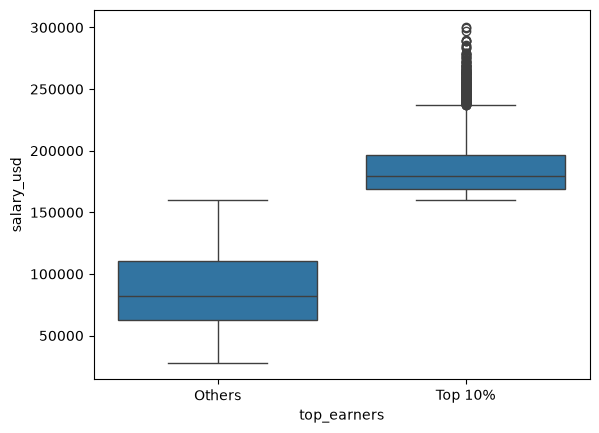

In [17]:
salary_threshold = df["salary_usd"].quantile(0.90)

df["top_earners"] = df["salary_usd"].apply(
    lambda x: "Top 10%" if x >= salary_threshold else "Others"
)

top_earner_summary = (
    df.groupby("top_earners")
      .agg(
          Median_Salary=("salary_usd", "median"),
          Median_Experience=("experience_years", "median"),
          Median_Bonus=("bonus_usd", "median"),
          Median_Satisfaction=("employee_satisfaction", "median"),
          Median_Job_Security=("job_security_score", "median"),
          Median_Promotion_Speed=("promotion_speed", "median")
      )
)

# top_earner_summary

sns.boxplot(
    data=df,
    x = "top_earners",
    y = "salary_usd"
)

plt.show()

In [30]:
# df["CAS"] = (
#     df["salary_usd"] * 0.25 +
#     df["career_growth_score"] * 0.20 +
#     df["job_security_score"] * 0.15 +
#     df["employee_satisfaction"] * 0.15 +
#     df["work_life_balance_score"] * 0.15 +
#     df["promotion_speed"] * 0.10 -

#     df["layoff_risk"] * 0.1 -
#     df["automation_risk"] * 0.1

#  ).round(2)

# df["CAS"]


df["salary_scaled"] = (
            (df["salary_usd"] - df["salary_usd"].min()) /
            (df["salary_usd"].max() - df["salary_usd"].min())
        ).round(2)

df["salary_scaled"].describe()

count    90000.000000
mean         0.251425
std          0.161195
min          0.000000
25%          0.130000
50%          0.220000
75%          0.350000
max          1.000000
Name: salary_scaled, dtype: float64

<Axes: xlabel='salary_usd', ylabel='CAS'>

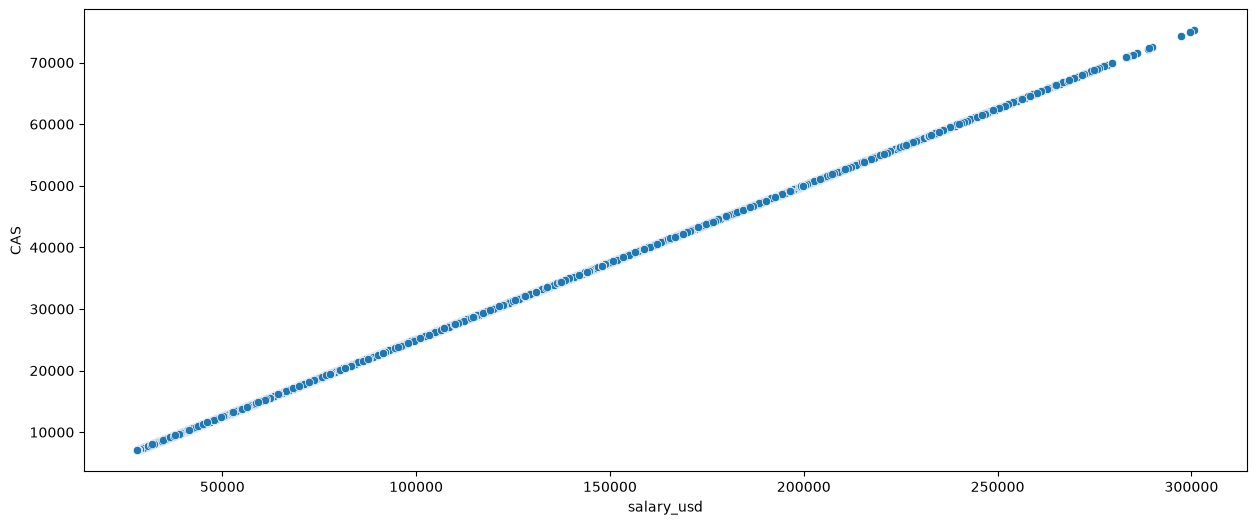

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))

sns.scatterplot(data=df, x="salary_usd", y="CAS")
plt.plot()
plt.show()



sns.histplot(data=df, x = "CAS")
sns.barplot(data=df, x = "job_role", y = "CAS")